# 1.8.Visualize confounding effects by cell line and seeding density
This notebook:
1. Reads in nested regression results generated and written in 1.7.
2. Visualizes confounding and sensitivity against cell line and density and seeding density.
3. Visualizes burden across all metric and degradation types against cell line and seeding density.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from utils.nested_regression_plot import (
    compute_burden_df,
    plot_nested_r2_multi,
    plot_burden_heatmaps,
)
from utils.validate_config import load_degradation_plot_config

## Pathing

In [2]:
output_dir = Path(".") / "results" / "bio_covariate_nested_regression"
if not output_dir.exists():
    raise FileNotFoundError(f"Output directory {output_dir} does not exist. Please run the previous steps to generate the results.")

cell_line_summary_file = output_dir / "boot_nest_cell_line_summary.parquet"
seeding_density_summary_file = output_dir / "boot_nest_seeding_density_summary.parquet"

if not cell_line_summary_file.exists() or not seeding_density_summary_file.exists():
    raise FileNotFoundError(
        f"Required summary Parquet files do not exist in {output_dir}. "
        "Please run notebook 1.7 to generate the results.")

cell_line_summary = pd.read_parquet(cell_line_summary_file)
seeding_density_summary = pd.read_parquet(seeding_density_summary_file)

In [3]:
degradation_plot_config = load_degradation_plot_config("degradation_plot_config.yaml")

METRIC_ORDER = degradation_plot_config["metrics"]["order"]
METRIC_LABELS = degradation_plot_config["metrics"]["labels"]
METRIC_PALETTE = degradation_plot_config["metrics"]["palette"]
TRANSFORM_ORDER = degradation_plot_config["transforms"]["order"]
TRANSFORM_LABELS = degradation_plot_config["transforms"]["labels"]

ABLATION_MARKERS = {
    "dilate": "o",
    "erode": "^",
    "gaussian_blur": "s",
    "gauss_noise": "D",
    "grid_distortion": "*",
    "random_gamma": "P",
}

In [4]:
summary_df = pd.concat(
    [
        cell_line_summary.assign(partial_term="Cell line"),
        seeding_density_summary.assign(partial_term="Seeding density")
    ],
    axis=0,
    ignore_index=True
)

summary_df.head()

,metric_name,transform_name,n_boot,restricted_r2_mean,restricted_r2_lower,restricted_r2_upper,partial_r2_mean,partial_r2_lower,partial_r2_upper,partial_term
0,dists,dilate,100,0.392960,0.390059,0.395183,0.067151,0.065388,0.068550,Cell line
1,dists,erode,100,0.495940,0.493174,0.498843,0.074723,0.073146,0.076254,Cell line
2,dists,gauss_noise,100,0.600204,0.598344,0.602062,0.006527,0.006073,0.007120,Cell line
3,dists,gaussian_blur,100,0.146033,0.144116,0.148181,0.075898,0.074458,0.077322,Cell line
4,dists,grid_distortion,100,0.658157,0.656236,0.659878,0.033831,0.032781,0.034731,Cell line


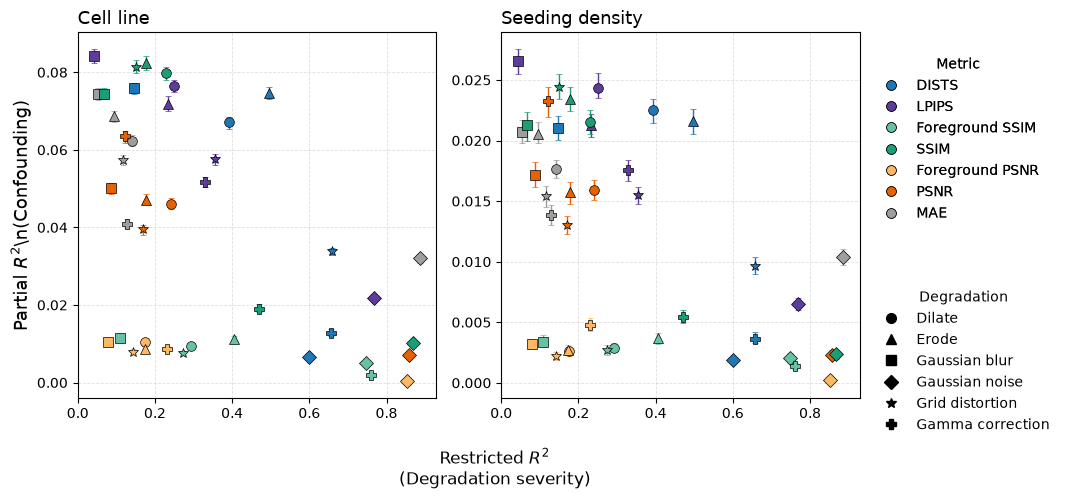

(<Figure size 1000x500 with 2 Axes>,
 [<Axes: title={'left': 'Cell line'}, ylabel='Partial $R^2$\\n(Confounding)'>,
  <Axes: title={'left': 'Seeding density'}>])

In [5]:
plot_nested_r2_multi(
    summary_df,
    restricted_term="Degradation severity",
    partial_terms=["Cell line", "Seeding density"],
    sharey=False,
    metric_labels=METRIC_LABELS,
    metric_colors=METRIC_PALETTE,
    metric_order=METRIC_ORDER,
    transform_labels=TRANSFORM_LABELS,
    transform_markers=ABLATION_MARKERS,
    output_path=output_dir / "nested_r2_scatter.png",
    dpi=300,
    show=True
)

In [6]:
cell_burden_df = compute_burden_df(
    data=cell_line_summary,
    confounder_label="Cell line",
)

density_burden_df = compute_burden_df(
    data=seeding_density_summary,
    confounder_label="Seeding density / confluence",
)

burden_df = pd.concat(
    [
        cell_burden_df,
        density_burden_df,
    ],
    ignore_index=True,
)

burden_df.head()

,metric_name,transform_name,n_boot,restricted_r2_mean,restricted_r2_lower,restricted_r2_upper,partial_r2_mean,partial_r2_lower,partial_r2_upper,confounder,burden
0,dists,dilate,100,0.392960,0.390059,0.395183,0.067151,0.065388,0.068550,Cell line,0.171097
1,dists,erode,100,0.495940,0.493174,0.498843,0.074723,0.073146,0.076254,Cell line,0.150840
2,dists,gauss_noise,100,0.600204,0.598344,0.602062,0.006527,0.006073,0.007120,Cell line,0.011040
3,dists,gaussian_blur,100,0.146033,0.144116,0.148181,0.075898,0.074458,0.077322,Cell line,0.520063
4,dists,grid_distortion,100,0.658157,0.656236,0.659878,0.033831,0.032781,0.034731,Cell line,0.051547


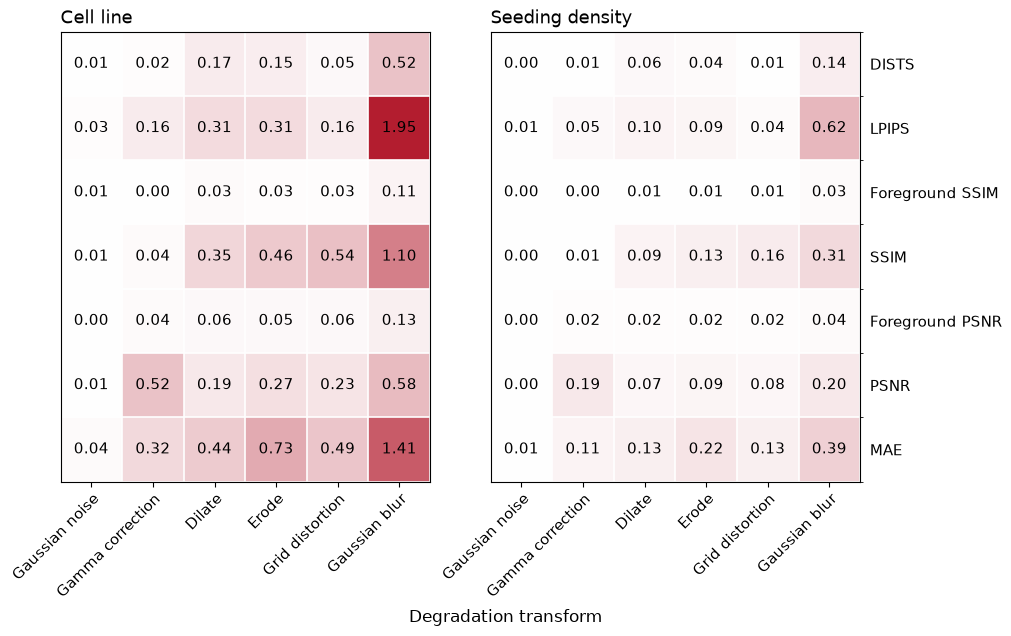

In [7]:
fig, axes, burden_df = plot_burden_heatmaps(
    confounder_data={
        "Cell line": cell_line_summary,
        "Seeding density": seeding_density_summary,
    },
    metric_labels=METRIC_LABELS,
    metric_order=METRIC_ORDER,
    transform_labels={key: value.replace("\n", " ") for key, value in TRANSFORM_LABELS.items()},
    transform_order=TRANSFORM_ORDER,
    title=None,
    output_path=output_dir / "burden_heatmaps.png",
    figsize=(10, 6.25),
    dpi=300,
    show=True
)

plt.show()